##Limpieza de datos

In [ ]:
!apt-get update -qq
!apt-get install -qq openjdk-8-jdk-headless
!wget -qO /content/spark.tgz \
    https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar -xzf /content/spark.tgz -C /content

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libxtst6:amd64.
(Reading database ... 126319 files and directories currently installed.)
Preparing to unpack .../libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package openjdk-8-jre-headless:amd64.
Preparing to unpack .../openjdk-8-jre-headless_8u452-ga~us1-0ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-8-jre-headless:amd64 (8u452-ga~us1-0ubuntu1~22.04) ...
Selecting previously unselected package openjdk-8-jdk-headless:amd64.
Preparing to unpack .../openjdk-8-jdk-headless_8u452-ga~us1-0ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-8-jdk-headless:amd64 (8u452-ga~us1-0ubuntu1~22.04) ...
Setting up libxtst6:amd64 (2:1.2.3-1build4) ...
Setting up openjdk-8-jre-headless:amd64 (8u452-ga~us1-0ubu

In [ ]:
import os

os.environ["JAVA_HOME"]  = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"
os.environ["HADOOP_HOME"]= os.environ["SPARK_HOME"]
os.environ["PATH"]      += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "bin")

!pip install -q pyspark findspark

In [ ]:
import findspark
findspark.init(os.environ["SPARK_HOME"])

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
import pandas as pd


spark = SparkSession.builder \
    .appName("Integracion_OIJ_INEC") \
    .master("local[*]") \
    .getOrCreate()

print("✅ Spark v" + spark.version + " listo")

tablas = pd.read_html("oij.xls")
oij_pd = tablas[0]

schema_oij = StructType([
    StructField("Delito",      StringType(),  True),
    StructField("SubDelito",   StringType(), True),
    StructField("Fecha",       StringType(), True),
    StructField("Hora",        StringType(),  True),
    StructField("Victima",     StringType(), True),
    StructField("SubVictima",  StringType(), True),
    StructField("Edad",        StringType(),  True),
    StructField("Sexo",        StringType(), True),
    StructField("Nacionalidad",StringType(), True),
    StructField("Provincia",   StringType(), True),
    StructField("Canton",      StringType(), True),
    StructField("Distrito",    StringType(), True),
])

oij = spark.createDataFrame(oij_pd, schema=schema_oij)

oij.printSchema()
oij.show(5, truncate=False)


censo_pd = pd.read_excel("statscenso11_22.xls", engine="xlrd")

censo_pd = censo_pd.rename(columns={
    'Provincia, cantón y distrito': 'Distrito',
    'Población de 15 años y más': 'Poblacion_15_mas',
    'Tasa neta de participación': 'Tasa_neta_participacion',
    'Tasa de ocupación': 'Tasa_ocupacion',
    'Tasa de desempleo abierto': 'Tasa_desempleo_abierto',
    'Porcentaje de población económicamente inactiva': 'Porcentaje_inactiva',
    'Relación de dependencia económica': 'Relacion_dependencia_economica',
    'Sector \nPrimario': 'Sector_Primario',
    'Sector \nSecundario': 'Sector_Secundario',
    'Sector Terciario': 'Sector_Terciario'
})

schema_censo = StructType([
    StructField("Distrito", StringType(), True),
    StructField("Poblacion_15_mas", DoubleType(), True),
    StructField("Tasa_neta_participacion", DoubleType(), True),
    StructField("Tasa_ocupacion", DoubleType(), True),
    StructField("Tasa_desempleo_abierto", StringType(), True),
    StructField("Porcentaje_inactiva", DoubleType(), True),
    StructField("Relacion_dependencia_economica", DoubleType(), True),
    StructField("Sector_Primario", DoubleType(), True),
    StructField("Sector_Secundario", DoubleType(), True),
    StructField("Sector_Terciario", DoubleType(), True)
])

censo = spark.createDataFrame(censo_pd, schema=schema_censo)

censo.printSchema()
censo.show(5, truncate=False)

✅ Spark v3.4.1 listo
root
 |-- Delito: string (nullable = true)
 |-- SubDelito: string (nullable = true)
 |-- Fecha: string (nullable = true)
 |-- Hora: string (nullable = true)
 |-- Victima: string (nullable = true)
 |-- SubVictima: string (nullable = true)
 |-- Edad: string (nullable = true)
 |-- Sexo: string (nullable = true)
 |-- Nacionalidad: string (nullable = true)
 |-- Provincia: string (nullable = true)
 |-- Canton: string (nullable = true)
 |-- Distrito: string (nullable = true)

+------+-----------+----------+-------------------+-------+----------------+-------------+------+------------+----------+----------+-------------+
|Delito|SubDelito  |Fecha     |Hora               |Victima|SubVictima      |Edad         |Sexo  |Nacionalidad|Provincia |Canton    |Distrito     |
+------+-----------+----------+-------------------+-------+----------------+-------------+------+------------+----------+----------+-------------+
|ASALTO|ARMA BLANCA|2011-01-10|18:00:00 - 20:59:59|PERSONA|PEATO

In [ ]:
from pyspark.sql.functions import trim, lower, col
from pyspark.sql import DataFrame

def limpia_espacios(df: DataFrame, columna: str = "Distrito") -> DataFrame:
    return df.withColumn(columna, trim(col(columna)))

def a_minusculas(df: DataFrame, columna: str = "Distrito") -> DataFrame:
    return df.withColumn(columna, lower(col(columna)))

# Aplica ambas a OIJ y Censo
oij_clean   = a_minusculas(limpia_espacios(oij))
censo_clean = a_minusculas(limpia_espacios(censo))

def distritos_no_en_inec(oij_df: DataFrame, inec_df: DataFrame) -> list:
    inec_dist = inec_df.select("Distrito").distinct()
    no_match = (
        oij_df.select("Distrito").distinct()
              .join(inec_dist, on="Distrito", how="left_anti")
    )
    return [row["Distrito"] for row in no_match.collect()]

def cuenta_no_en_inec(oij_df: DataFrame, inec_df: DataFrame) -> int:
    inec_dist = inec_df.select("Distrito").distinct()
    no_match_df = oij_df.join(inec_dist, on="Distrito", how="left_anti")
    return no_match_df.count()

mismatched = distritos_no_en_inec(oij_clean, censo_clean)
count_bad   = cuenta_no_en_inec  (oij_clean, censo_clean)

print("Distritos OIJ sin match en INEC:", mismatched)
print("Cantidad de registros sin match:", count_bad)

censo_clean.createOrReplaceTempView("censo_tmp")

censo_fixed = spark.sql("""
SELECT
  CASE
    WHEN Distrito = 'rio cuarto' THEN 'río cuarto'
    WHEN Distrito = 'san jeronimo' THEN 'san jerónimo'
    WHEN Distrito = 'libano' THEN 'líbano'
    WHEN Distrito = 'colon' THEN 'colón'
    WHEN Distrito = 'santa lucia' THEN 'santa lucía'
    WHEN Distrito = 'belen' THEN 'belén'
    WHEN Distrito = 'santo tomas' THEN 'santo tomás'
    WHEN Distrito = 'tarcoles' THEN 'tárcoles'
    WHEN Distrito = 'alegria' THEN 'alegría'
    WHEN Distrito = 'patarra' THEN 'patarrá'
    WHEN Distrito = 'san sebastian' THEN 'san sebastían'
    WHEN Distrito = 'pavon' THEN 'pavón'
    WHEN Distrito = 'rio blanco' THEN 'río blanco'
    ELSE Distrito
  END AS Distrito,
  Poblacion_15_mas,
  Tasa_neta_participacion,
  Tasa_ocupacion,
  Tasa_desempleo_abierto,
  Porcentaje_inactiva,
  Relacion_dependencia_economica,
  Sector_Primario,
  Sector_Secundario,
  Sector_Terciario
FROM censo_tmp
""")


joined = oij_clean.join(
    censo_fixed.select("Distrito", *[c for c in censo_fixed.columns if c!="Distrito"]),
    on="Distrito",
    how="inner"
)

print("Registros tras el join:", joined.count())
joined.show(5, truncate=False)

Distritos OIJ sin match en INEC: ['rio cuarto', 'san jeronimo', 'libano', 'para', 'colon', 'guapiles', 'guacimo', 'puraba', 'cajon', 'belen', 'belen de nosarita', 'granja', 'santa lucia', 'desconocido', 'santo tomas', 'agua buena', 'tarcoles', 'alegria', 'santa maria', 'patarra', 'san sebastian', 'cirri sur', 'cortes', 'san jose de la monta?a', 'palmera', 'pavon', 'canas dulces', 'sanchez', 'llanos de santa lucia', 'rio blanco', 'juan vinas', 'general', 'baru', 'rio azul', 'volcan', 'horquetas', 'bahia ballena', 'rio jimenez', 'ceiba', 'sarchi norte', 'dulce nombre de jesus', 'guacima', 'la legua', 'san jose', 'san ramon', 'aserri', 'dos rios', 'mastate', 'guaycara', 'fortuna', 'sarchi sur', 'cobano', 'san cristobal', 'paramo', 'jesus maria', 'angeles', 'curubande', 'jaco', 'tapezco', 'tres rios', 'san nicolas', 'jesus', 'batan', 'paraiso', 'cachi', 'tilaran', 'espiritu santo', 'merecedes', 'canas', 'mansion', 'rio segundo', 'limon', 'samara', 'tigra', 'mata platano', 'cano negro', 'ca

In [ ]:
!pip install psycopg2

In [ ]:
!pip install SQLAlchemy

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [ ]:
USER = "postgres.fxfhdqxywfqiwpwgghck"
PASSWORD = "sdjh3e#9sdLsaopaAwre435"
HOST = "aws-0-us-east-2.pooler.supabase.com"
PORT = "6543"
DBNAME = "postgres"

In [ ]:
import psycopg2
# Establecer conexión
try:
    conn = psycopg2.connect(
        host=HOST,
        port=PORT,
        dbname=DBNAME,
        user=USER,
        password=PASSWORD
    )

    cursor = conn.cursor()
    cursor.execute("SELECT nombre FROM usuarios LIMIT 5;")
    rows = cursor.fetchall()

    for row in rows:
        print(row)

    cursor.close()
    conn.close()

except Exception as e:
    print("❌ Error de conexión:",e)

('Juan',)
('Ana',)


##Aquí se cargan los datos previos hasta supabase

In [ ]:
!pip install -q sqlalchemy psycopg2-binary

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    "postgresql+psycopg2",
    username=USER,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DBNAME,
    query={"sslmode": "require"}  # ← clave en Supabase
)

engine = create_engine(url)

# Spark ➜ Pandas
joined_pd = joined.toPandas()

# Sube a la tabla (crea o reemplaza)
joined_pd.to_sql(
    name="oij_inec",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=2_000       # ajusta el tamaño de lote
)

engine.dispose()
print("✅ Cargado vía Pandas/SQLAlchemy")


✅ Cargado vía Pandas/SQLAlchemy


#Grafico 1

In [ ]:
import psycopg2, pandas as pd

def get_conn():
    return psycopg2.connect(
        host=HOST, port=PORT, dbname=DBNAME,
        user=USER, password=PASSWORD, sslmode="require"
    )

with get_conn() as conn:                     # abre y cierra automáticamente
    df = pd.read_sql(sql, conn)


/tmp/ipython-input-16-4131837489.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


In [ ]:
!pip install seaborn

/tmp/ipython-input-22-673944234.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


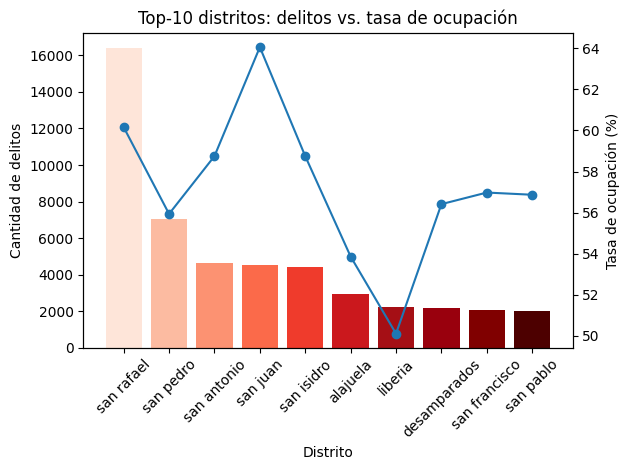

In [ ]:
# ── 1 ▸ Consulta SQL: top-10 distritos con más delitos ────────────────
sql = """
WITH agg AS (
  SELECT
    "Distrito"                       AS distrito,
    COUNT(*)                         AS delitos,
    MAX("Tasa_ocupacion"::float8)    AS tasa_ocupacion
  FROM public.oij_inec
  GROUP  BY "Distrito"
)
SELECT *
FROM   agg
ORDER  BY delitos DESC
LIMIT  10;
"""

# Usa la conexión que YA tienes (conn)
import pandas as pd
df = pd.read_sql(sql, conn)

# ── 2 ▸ Gráfico: barras + línea ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Barras = cantidad de delitos
palette = [
    "#fee5d9",
    "#fcbba1",
    "#fc9272",
    "#fb6a4a",
    "#ef3b2c",
    "#cb181d",
    "#a50f15",
    "#99000d",
    "#800000",
    "#4d0000"
]
ax1.bar(df['distrito'], df['delitos'], color=palette)
ax1.set_xlabel("Distrito")
ax1.set_ylabel("Cantidad de delitos")

# Línea = tasa de ocupación (eje secundario)
ax2 = ax1.twinx()
ax2.plot(df["distrito"], df["tasa_ocupacion"], marker="o")
ax2.set_ylabel("Tasa de ocupación (%)")
ax1.tick_params(axis='x',
                labelrotation=45)
#plt.xticks(rotation=45, ha="right")
plt.title("Top-10 distritos: delitos vs. tasa de ocupación")

plt.tight_layout()
plt.show()


#Gráfico 2

Distrito con más delitos: san rafael


/tmp/ipython-input-23-1970731957.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("Purples")(np.linspace(0.55, 1.0, n))


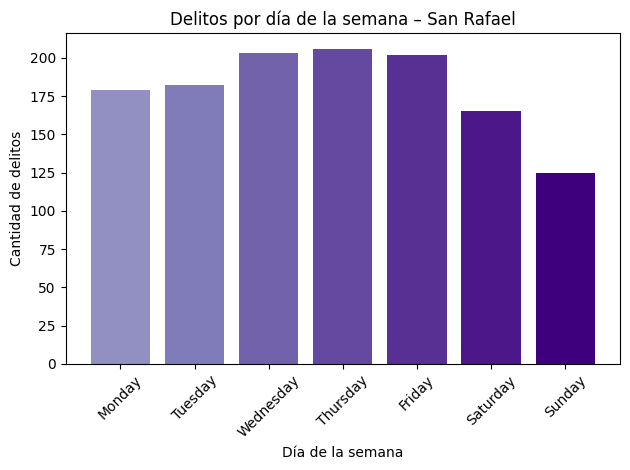

In [ ]:
from pyspark.sql.functions import to_date, date_format, col, desc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# ------------------------------------------------------------------
# 1 ▸ Distrito con más delitos
top_distrito = (
    oij_clean.groupBy("Distrito")
             .count()
             .orderBy(desc("count"))
             .first()["Distrito"]
)
print("Distrito con más delitos:", top_distrito)

# ------------------------------------------------------------------
# 2 ▸ Delitos por día de la semana
delitos_dow = (
    oij_clean.filter(col("Distrito") == top_distrito)
             .withColumn("Fecha_dt",  to_date(col("Fecha"), "yyyy-MM-dd"))
             .withColumn("dia_semana", date_format(col("Fecha_dt"), "EEEE"))
             .groupBy("dia_semana")
             .count()
)

# ------------------------------------------------------------------
# 3 ▸ DataFrame Pandas ordenado L-D
dias_orden = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
delitos_pd = delitos_dow.toPandas()
delitos_pd["dia_semana"] = pd.Categorical(delitos_pd["dia_semana"],
                                          categories=dias_orden, ordered=True)
delitos_pd = delitos_pd.sort_values("dia_semana")

# ------------------------------------------------------------------
# 4 ▸ Paleta morada (Purples, tramo 0.55–1.0)
n = len(delitos_pd)
palette = cm.get_cmap("Purples")(np.linspace(0.55, 1.0, n))

# ------------------------------------------------------------------
# 5 ▸ Gráfico
plt.bar(delitos_pd["dia_semana"], delitos_pd["count"], color=palette)
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de delitos")
plt.title(f"Delitos por día de la semana – {top_distrito.title()}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Grafico 3

/tmp/ipython-input-24-3407548758.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("Purples")(np.linspace(0.55, 1.0, n))


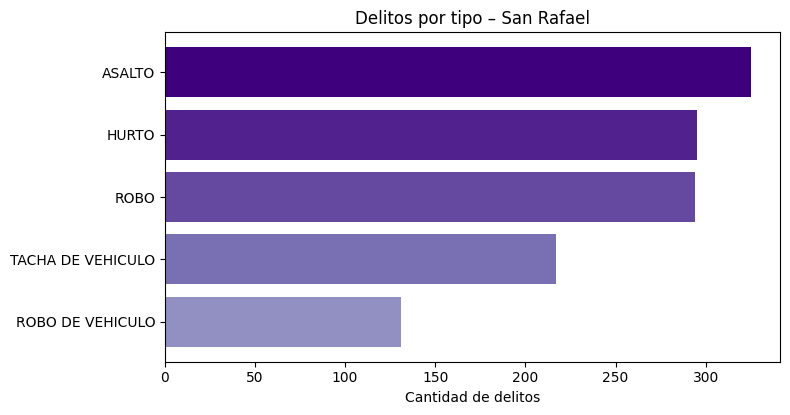

In [ ]:
from pyspark.sql.functions import col, desc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# ── 1 ▸ Cantidad de delitos por tipo (sólo el distrito seleccionado) ──────────
delitos_tipo = (
    oij_clean.filter(col("Distrito") == top_distrito)
             .groupBy("Delito")
             .count()
             .orderBy(desc("count"))
)

# ── 2 ▸ Pasa a Pandas y, si hay muchos tipos, deja los 15 primeros ───────────
delitos_tipo_pd = delitos_tipo.toPandas()
top_n = 15
delitos_tipo_pd = delitos_tipo_pd.head(top_n)

# Orden inverso para que la barra más grande quede arriba
delitos_tipo_pd = delitos_tipo_pd.iloc[::-1]

# ── 3 ▸ Paleta morada oscura ─────────────────────────────────────────────────
n = len(delitos_tipo_pd)
palette = cm.get_cmap("Purples")(np.linspace(0.55, 1.0, n))

# ── 4 ▸ Gráfico ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 0.45 * n + 2))
plt.barh(delitos_tipo_pd["Delito"], delitos_tipo_pd["count"], color=palette)
plt.xlabel("Cantidad de delitos")
plt.title(f"Delitos por tipo – {top_distrito.title()}")
plt.tight_layout()
plt.show()


#Grafico 4

/tmp/ipython-input-25-109818442.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("Blues")(np.linspace(0.4, 0.9, n))


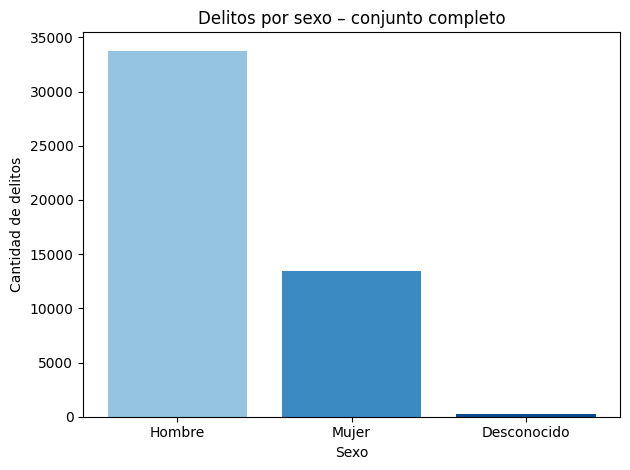

In [ ]:
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# 1 ▸ Conteo de delitos por sexo (en todo el conjunto)
delitos_sexo = (
    oij_clean.groupBy("Sexo")
             .count()
             .orderBy(col("count").desc())
)

# 2 ▸ A Pandas para graficar
df_sexo = delitos_sexo.toPandas()

# 3 ▸ Paleta automática (colormap Blues, parte media-oscura)
n = len(df_sexo)
palette = cm.get_cmap("Blues")(np.linspace(0.4, 0.9, n))

# 4 ▸ Gráfico
plt.bar(df_sexo["Sexo"].str.title(), df_sexo["count"], color=palette)
plt.xlabel("Sexo")
plt.ylabel("Cantidad de delitos")
plt.title("Delitos por sexo – conjunto completo")
plt.tight_layout()
plt.show()


#Grafico 5

/tmp/ipython-input-26-1091005329.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("Oranges")(np.linspace(0.4, 0.9, n))


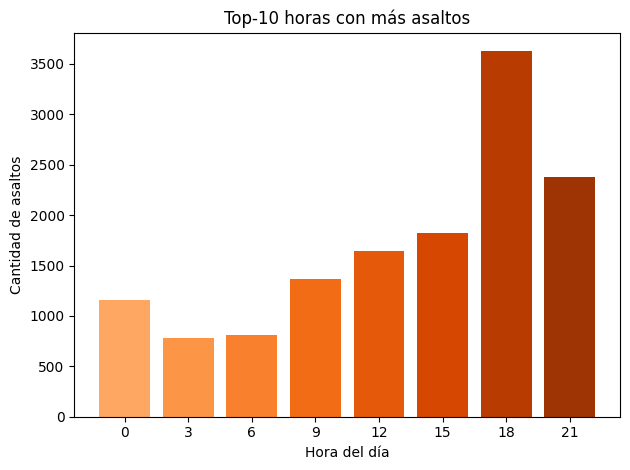

In [ ]:
from pyspark.sql.functions import col, lower, substring, desc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# 1 ▸ Filtra solo los asaltos
asaltos = oij_clean.filter(lower(col("Delito")).contains("asalto"))

# 2 ▸ Extrae la hora (primeros 2 caracteres de HH:MM o HH:MM:SS)
asaltos = asaltos.withColumn("hora", substring(col("Hora"), 1, 2).cast("int"))

# 3 ▸ Conteo de asaltos por hora
asaltos_x_hora = (
    asaltos.groupBy("hora")
           .count()
           .orderBy(desc("count"))
)

# 4 ▸ Toma las 10 horas con más asaltos
top_horas = asaltos_x_hora.limit(10).toPandas().sort_values("hora")

# 5 ▸ Gráfico
n = len(top_horas)
palette = cm.get_cmap("Oranges")(np.linspace(0.4, 0.9, n))

plt.bar(top_horas["hora"].astype(str), top_horas["count"], color=palette)
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de asaltos")
plt.title("Top-10 horas con más asaltos")
plt.tight_layout()
plt.show()
